# Proceso de convolución en imágenes

### 1. Representación de la imagen y el filtro

- Denotemos la **imagen** como una matriz real:
  $$
  I \in \mathbb{R}^{m \times n}
  $$
  donde $m$ es el número de filas (alto) y $n$ es el número de columnas (ancho).

- Denotemos el **filtro (o kernel)** como:
  $$
  K \in \mathbb{R}^{p \times q}
  $$
  donde normalmente $p, q$ son pequeños (por ejemplo, $p=q=3$ para un filtro $3 \times 3$).

---

### 2. Definición de la operación de convolución

La **convolución discreta** entre $I$ y $K$ genera una nueva matriz $O$ (output) donde cada elemento es:
$$
O(i,j) = \sum_{u=0}^{p-1} \sum_{v=0}^{q-1} K(u,v) \cdot I(i+u, j+v)
$$
para cada posición $(i,j)$ donde la operación es válida.

**Notas**:
- Aquí no se está haciendo "flip" del kernel (lo cual técnicamente sería necesario para una convolución pura); en procesamiento de imágenes, frecuentemente se usa directamente el *cross-correlation* en lugar de la convolución matemática estricta.
- Se asume que no hay padding: el tamaño del output será $(m-p+1)\times (n-q+1)$.
- El índice $(i,j)$ recorre solo posiciones donde el filtro cabe completamente sobre la imagen.

---

### 3. Forma alternativa con notación matricial expandida

Cada valor $O(i,j)$ puede verse como el **producto interno** entre:
- el sub-bloque de la imagen $I$ de tamaño $p \times q$ comenzando en $(i,j)$,
- y el filtro \(K\).

Esto se puede expresar como:

$$
O(i,j) = \langle I_{(i:i+p-1, j:j+q-1)}, K \rangle
$$

donde $\langle \cdot, \cdot \rangle$ denota el producto interno de matrices, es decir:

$$
\langle A, B \rangle = \sum_{u,v} A(u,v) B(u,v)
$$

En palabras: **multiplica elemento a elemento y suma todo**.

---

### 4. Ejemplo numérico pequeño

Supongamos:

$$
I = \begin{bmatrix}
1 & 2 & 0 & 1\\
4 & 1 & 2 & 2\\
1 & 3 & 0 & 0\\
2 & 1 & 3 & 1
\end{bmatrix}
\quad
K = \begin{bmatrix}
1 & 0\\
0 & -1
\end{bmatrix}
$$

El primer valor del output sería:

$$
O(0,0) = 1 \cdot 1 + 2 \cdot 0 + 4 \cdot 0 + 1 \cdot (-1) = 1 + 0 + 0 - 1 = 0
$$

Se sigue avanzando desplazando el filtro sobre la imagen.

---

### 5. Resumen final

**Convolución en imágenes** usando notación matricial:

- Imagen: $I \in \mathbb{R}^{m \times n}$
- Filtro: $K \in \mathbb{R}^{p \times q}$
- Output (sin padding): $O \in \mathbb{R}^{(m-p+1) \times (n-q+1)}$
- Operación en cada punto:

$$
O(i,j) = \sum_{u=0}^{p-1} \sum_{v=0}^{q-1} K(u,v) \cdot I(i+u, j+v)
\quad \text{equivalentemente} \quad
O(i,j) = \langle I_{(i:i+p-1, j:j+q-1)}, K \rangle
$$

In [1]:
import numpy as np

In [7]:
I = np.array([[1, 2, 0, 1],[4, 1, 2, 2],[1, 3, 0, 0], [2, 1, 3, 1]])
K = np.array([[1, 0], [0, -1]])

In [12]:
Z = np.zeros((3,3))
for j in range(3):
    for i in range(3):
        Is = I[i:(i+2),j:(j+2)]
        Z[i,j] = np.sum(np.multiply(Is,K))

In [13]:
Z

array([[ 0.,  0., -2.],
       [ 1.,  1.,  2.],
       [ 0.,  0., -1.]])

# Ejemplo de código

1. Cargar una imagen base

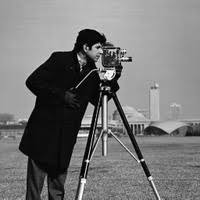

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image = Image.open("cameraman.jpeg").convert("L")

display(image)

Convertir la imagen a un array numpy

In [16]:
image = np.array(image)
print(image)
print(image.shape)


[[156 156 157 ... 153 153 153]
 [156 156 157 ... 153 153 153]
 [156 156 157 ... 152 152 152]
 ...
 [122 127 106 ... 127 131 123]
 [132 133 130 ... 145 140 116]
 [126 127 149 ... 116 125 118]]
(200, 200)


In [17]:
image.shape

(200, 200)

2. Agregar ruido sal y pimienta

In [18]:
def add_salt_and_pepper_noise(image, amount=0.05, salt_vs_pepper=0.5):
    noisy_image = image.copy()
    num_pixels = int(amount * image.size)
    
    # Sal
    coords = [np.random.randint(0, i - 1, num_pixels) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 255
    
    # Pimienta
    coords = [np.random.randint(0, i - 1, num_pixels) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 0

    return noisy_image

noisy_image = add_salt_and_pepper_noise(image, amount=0.001)

(-0.5, 199.5, 199.5, -0.5)

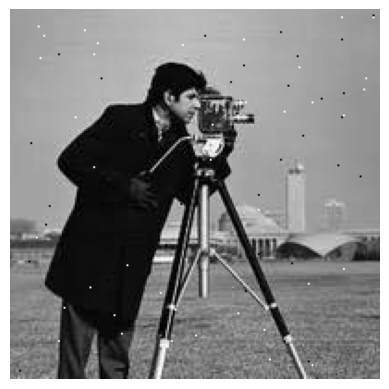

In [19]:
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

3. Definir un filtro promedio (3x3)

In [20]:
kernel = np.ones((3,3)) / 9

In [21]:
kernel

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

In [22]:
I = noisy_image.copy()
K = kernel.copy()
m, n = I.shape
p, q = K.shape

Z = np.zeros((m-p,n-q))
for j in range(n-q):
    for i in range(m-p):
        Is = I[i:(i+p),j:(j+q)]
        Z[i,j] = np.sum(np.multiply(Is,K))

(-0.5, 196.5, 196.5, -0.5)

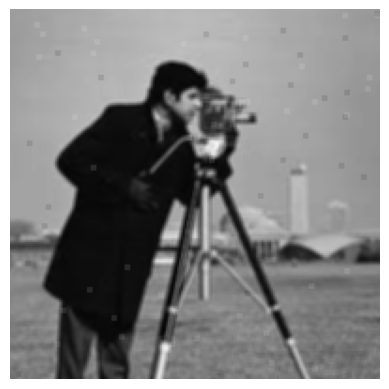

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(Z,vmin=0, vmax=255, cmap='gray')
plt.axis('off')

4. Aplicar convolución manual

In [7]:
def convolve(image, kernel):
    m, n = image.shape
    p, q = kernel.shape
    output = np.zeros((m - p + 1, n - q + 1))
    
    for i in range(m - p + 1):
        for j in range(n - q + 1):
            region = image[i:i+p, j:j+q]
            output[i,j] = np.sum(region * kernel)
    
    return output

# Aplicar la convolución
smoothed_image = convolve(noisy_image, kernel)

5. Mostrar las imágenes

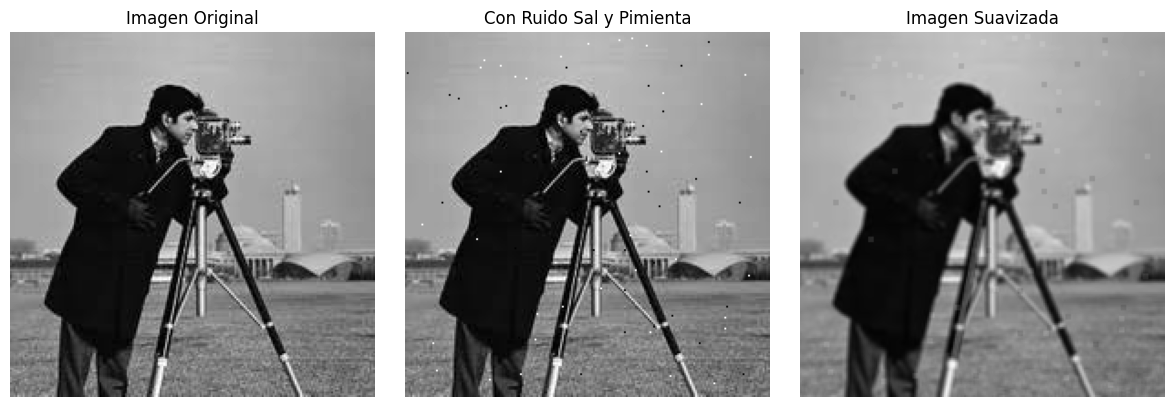

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Con Ruido Sal y Pimienta')
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Imagen Suavizada')
plt.imshow(smoothed_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

(-0.5, 187.5, 187.5, -0.5)

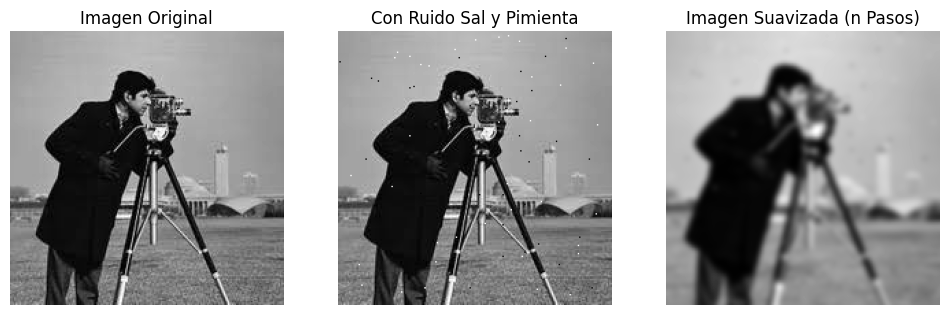

In [13]:
smoothed_image = convolve(smoothed_image, kernel)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Con Ruido Sal y Pimienta')
plt.imshow(noisy_image, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Imagen Suavizada (n Pasos)')
plt.imshow(smoothed_image, cmap='gray')
plt.axis('off')

### Ejercicio
Revisa el enlace: https://setosa.io/ev/image-kernels/ e implementa un código que aplique los kernels que allí se muestran. Compara el tiempo de ejecución al aplicar la convolución usando una implementación con ciclos *for* versus una implementación con *cv.filter2D* de OpenCV.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from cv2 import filter2D

image = Image.open("cameraman.jpeg").convert("L")
img = np.array(image)

In [15]:
import time

In [18]:
# kernel = np.array([[1, 0, -1],
#                    [1, 0, -1],
#                    [1, 0, -1]])

kernel = np.ones((3, 3), dtype=np.float32) / 9

# tiempo de ejecución
time_start = time.time()
output_img = filter2D(img, -1, kernel)
time_end = time.time()
print(f"Tiempo de ejecución: {time_end - time_start} segundos")

Tiempo de ejecución: 0.0 segundos


(-0.5, 199.5, 199.5, -0.5)

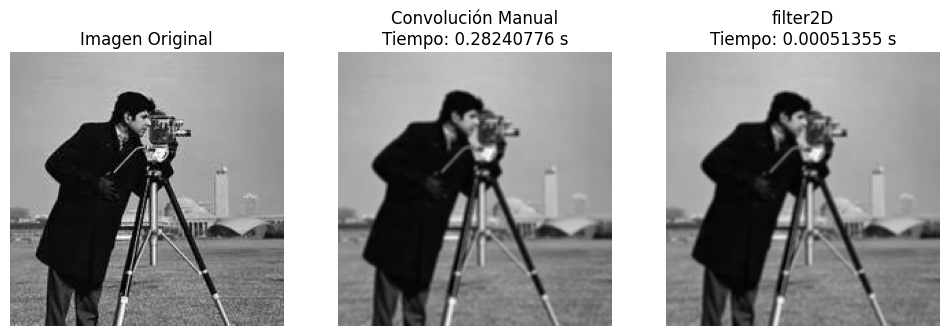

In [21]:
# Comparación filter2D vs convolución manual
# tiempo de ejecución para convolución manual
time_start_manual = time.time()
output_manual = convolve(img, kernel)
time_end_manual = time.time()
delta_time_manual = time_end_manual - time_start_manual

# tiempo de ejecución para filter2D
time_start_filter2D = time.time()
output_filter2D = filter2D(img, -1, kernel)
time_end_filter2D = time.time()
delta_time_filter2D = time_end_filter2D - time_start_filter2D

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title(f'Convolución Manual\nTiempo: {delta_time_manual:.8f} s')
plt.imshow(output_manual, cmap='gray')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title(f'filter2D\nTiempo: {delta_time_filter2D:.8f} s')
plt.imshow(output_filter2D, cmap='gray')
plt.axis('off')


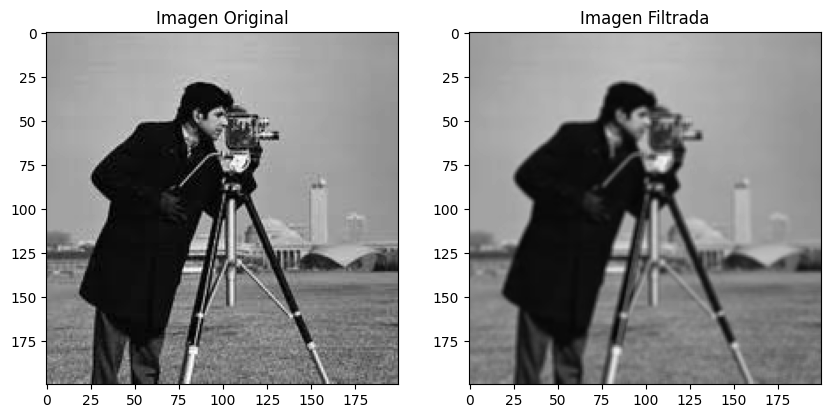

In [19]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(img, cmap='gray', vmin=0, vmax=255)

plt.subplot(1, 2, 2)
plt.title('Imagen Filtrada')
plt.imshow(output_img, cmap='gray', vmin=0, vmax=255)

# Operaciones morfológicas

In [22]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

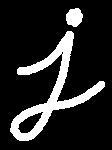

In [23]:
img = Image.open("jota.png").convert("L")
display(img)

(-0.5, 111.5, 149.5, -0.5)

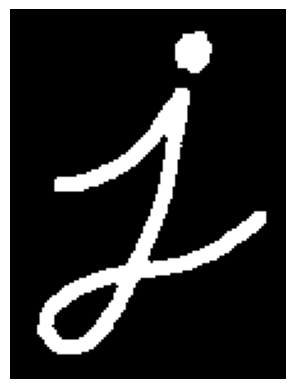

In [43]:
I = np.array(img)
# aplicar erosion
st_elem = np.array([[0, 1, 0],
                     [1, 1, 1],
                     [0, 1, 0]], dtype=np.uint8) # elemento estructurante
I_erosion = cv2.erode(I, st_elem, iterations=1)
plt.imshow(I_erosion, cmap='gray')
plt.axis('off')

(-0.5, 111.5, 149.5, -0.5)

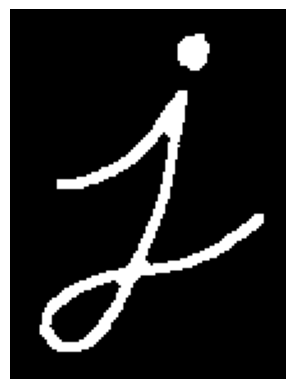

In [44]:
I_erosion = cv2.erode(I_erosion, st_elem, iterations=1)
plt.imshow(I_erosion, cmap='gray')
plt.axis('off')

(-0.5, 111.5, 149.5, -0.5)

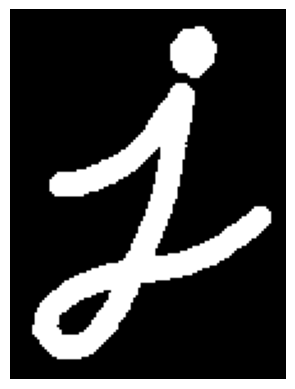

In [124]:
I = np.array(img)
# aplicar dilatacion
st_elem = np.array([[0, 1, 0],
                     [1, 1, 1],
                     [0, 1, 0]], dtype=np.uint8)
I_dilatacion = cv2.dilate(I, st_elem, iterations=1)
plt.imshow(I_dilatacion, cmap='gray')
plt.axis('off')

(-0.5, 111.5, 149.5, -0.5)

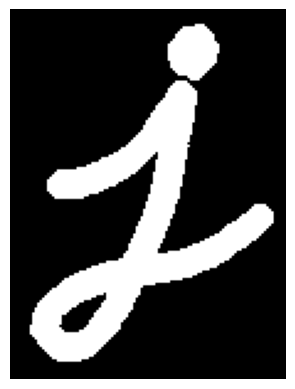

In [125]:
I_dilatacion = cv2.dilate(I_dilatacion, st_elem, iterations=1)
plt.imshow(I_dilatacion, cmap='gray')
plt.axis('off')

(-0.5, 111.5, 149.5, -0.5)

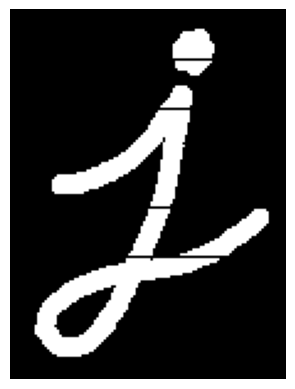

In [140]:
Icopy = I.copy()
Icopy[[20,40,80,100],:] = 0
plt.imshow(Icopy, cmap='gray')
plt.axis('off')

(-0.5, 111.5, 149.5, -0.5)

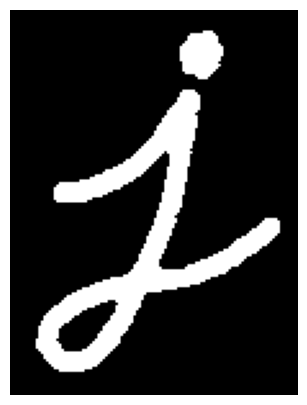

In [131]:
# Operación de cierre (closing) = dilatación + erosión
I_dilatacion = cv2.dilate(Icopy, st_elem, iterations=1)
I_cierre = cv2.erode(I_dilatacion, st_elem, iterations=1)
plt.figure(figsize=(10, 5))
plt.imshow(I_cierre, cmap='gray')
plt.axis('off')

(-0.5, 111.5, 149.5, -0.5)

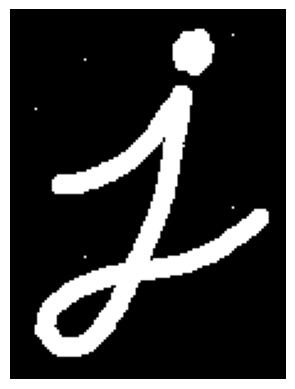

In [138]:
Icopy = I.copy()
Icopy[20,30] = 255
Icopy[40,10] = 255
Icopy[80,90] = 255
Icopy[100,30] = 255
Icopy[10,90] = 255

plt.imshow(Icopy, cmap='gray')
plt.axis('off')

(-0.5, 111.5, 149.5, -0.5)

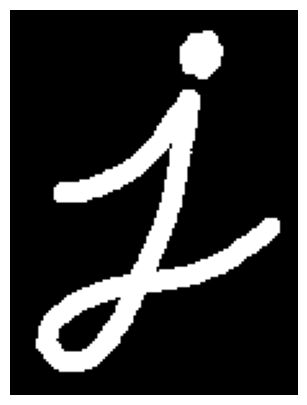

In [139]:
# Operación de apertura (opening) = erosión + dilatación
I_erosion = cv2.erode(Icopy, st_elem, iterations=1)
I_apertura = cv2.dilate(I_erosion, st_elem, iterations=1)
plt.figure(figsize=(10, 5))
plt.imshow(I_apertura, cmap='gray')
plt.axis('off')

# Ejercicio de clase

In [1]:
import numpy as np

In [2]:
Iz = np.array([[0, 0, 0, 0, 0],
               [0, 3, -1, 1, 0],
               [0, 2, 0, 2, 0],
               [0, 5, 4, -2, 0],
               [0, 0, 0, 0, 0]])

k2 = np.array([[-3, 1, -1],
                [4, 2, 3],
                [0, 1, 2]])

Iout = np.zeros((3, 3))

for i in range(3):
    for j in range(3):
        region = Iz[i:i+3, j:j+3]
        Iout[i, j] = np.sum(region * k2)

In [3]:
Iz.shape, k2.shape, Iout.shape

((5, 5), (3, 3), (3, 3))

In [4]:
Iout

array([[ 5., 17.,  0.],
       [21.,  3.,  6.],
       [24., 14., 14.]])

In [8]:
import cv2
import matplotlib.pyplot as plt

In [6]:
# Cargar imagen cameraman.jpeg
Icam = cv2.imread('cameraman.jpeg', cv2.IMREAD_GRAYSCALE)

In [7]:
Icam.shape

(200, 200)

(-0.5, 199.5, 199.5, -0.5)

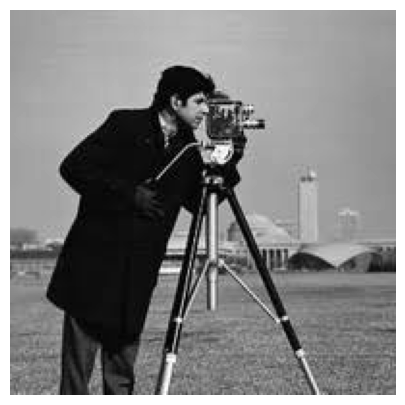

In [9]:
plt.figure(figsize=(10, 5))
plt.imshow(Icam, cmap='gray')
plt.axis('off')

In [15]:
Iz = Icam.copy()

k2 = np.array([[1, 1, 1],
                [0, 0, 0],
                [-1, -1, -1]])

nr, nc = Iz.shape
nor, noc = (nr - k2.shape[0] + 1, nc - k2.shape[1] + 1)
Iout = np.zeros((nor, noc))

for i in range(nor):
    for j in range(noc):
        region = Iz[i:i+k2.shape[0], j:j+k2.shape[1]]
        Iout[i, j] = np.sum(region * k2)

In [16]:
Iz.shape, k2.shape, Iout.shape

((200, 200), (3, 3), (198, 198))

(-0.5, 197.5, 197.5, -0.5)

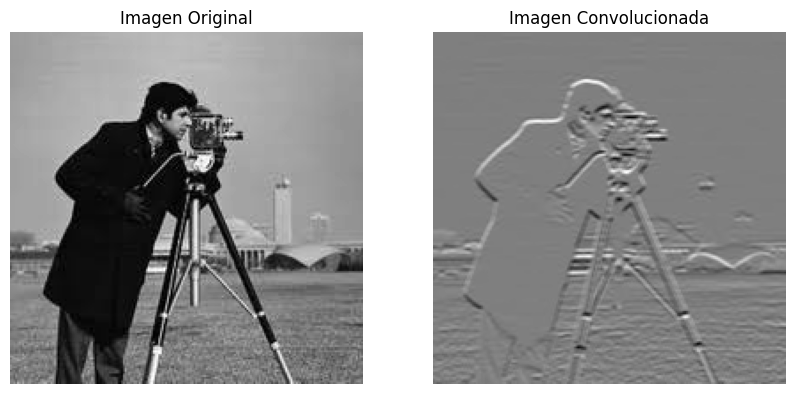

In [18]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(Icam, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Imagen Convolucionada')
plt.imshow(Iout, cmap='gray')
plt.axis('off')

In [19]:
def miconvolucion(I, k):
    nr, nc = I.shape
    kr, kc = k.shape
    nor, noc = (nr - kr + 1, nc - kc + 1)
    Iout = np.zeros((nor, noc))
    
    for i in range(nor):
        for j in range(noc):
            region = I[i:i+kr, j:j+kc]
            Iout[i, j] = np.sum(region * k)
    
    return Iout
    

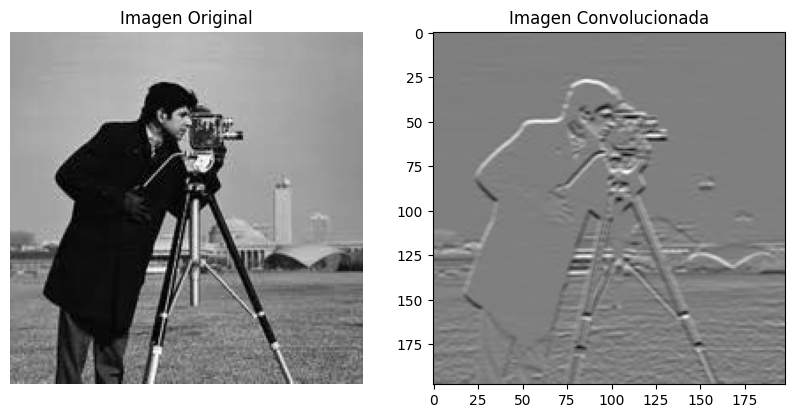

In [20]:
k2 = np.array([[1, 1, 1],
                [0, 0, 0],
                [-1, -1, -1]])
Iout = miconvolucion(Icam, k2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen Original')
plt.imshow(Icam, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Imagen Convolucionada')
plt.imshow(Iout, cmap='gray')